# EDA for Team Win/Loss Record

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
import os


In [2]:
# Establishing file paths for loading and saving data
CLEANED_PATH = "../../data/teams_cleaned"
PROCESSED_PATH = "../../data/processed"
os.makedirs(PROCESSED_PATH, exist_ok=True)

The first phase of EDA will be to determine which categories matter most for the DPOY award

In [3]:
# Importing the merged data set from notebook 01
teams_df = pd.read_csv(f"{CLEANED_PATH}/team_all_years.csv")

In [4]:
# Previewing the data to ensure this is the correct DataFrame
teams_df.head(5)

,Team,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,...,Pace,FTr,3PAr,TS%,eFG%,TOV%,ORB%,FT/FGA,DRB%,Season
0,Phoenix Suns,40.7,82.8,0.492,8.9,21.6,0.412,31.8,61.2,0.520,...,95.3,0.312,0.261,0.585,0.546,13.6,27.6,0.240,70.8,2010
1,Golden State Warriors,40.6,86.5,0.469,7.7,20.6,0.375,32.9,65.9,0.499,...,100.4,0.294,0.238,0.557,0.514,13.1,20.9,0.230,68.5,2010
2,Denver Nuggets,38.1,81.4,0.468,6.6,18.5,0.359,31.5,62.9,0.500,...,94.8,0.376,0.227,0.561,0.509,12.7,26.1,0.290,72.4,2010
3,Utah Jazz,39.4,80.2,0.491,5.4,14.7,0.364,34.0,65.5,0.519,...,93.8,0.340,0.184,0.565,0.524,14.2,26.8,0.252,75.6,2010
4,Toronto Raptors,39.0,80.9,0.482,6.3,17.0,0.371,32.7,63.8,0.512,...,93.1,0.319,0.211,0.564,0.521,12.7,24.7,0.244,72.9,2010


After reviewing the player data, we decided to add a column "has_Best_Record" so similar flags can be used for team data.

In [5]:
# Creating a helper column for determing the best record in a season
teams_df["Max_Wins"] = teams_df.groupby("Season")["W"].transform("max")

In [6]:
# Creating the has_Best_Record column
teams_df["has_Best_Record"] = teams_df["W"] == teams_df["Max_Wins"]

In [7]:
# Dropping the Max Wins column as it's no longer needed
teams_df.drop(columns=["Max_Wins"], inplace=True)

In [8]:
# Separate DataFrame for previewing best teams in a season
best_teams = teams_df[teams_df["has_Best_Record"]]

In [9]:
best_teams.head(5)

,Team,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,...,FTr,3PAr,TS%,eFG%,TOV%,ORB%,FT/FGA,DRB%,Season,has_Best_Record
8,Cleveland Cavaliers,37.8,77.9,0.485,7.3,19.3,0.381,30.5,58.6,0.520,...,0.341,0.248,0.570,0.532,13.4,25.1,0.246,77.2,2010,True
49,Chicago Bulls,37.1,80.3,0.462,6.2,17.3,0.361,30.9,63.1,0.489,...,0.305,0.215,0.541,0.501,13.5,29.4,0.227,76.2,2011,True
61,San Antonio Spurs,39.6,82.8,0.478,8.4,21.3,0.393,31.2,61.5,0.507,...,0.261,0.257,0.562,0.528,12.8,25.1,0.195,76.0,2012,True
77,Chicago Bulls,37.4,82.8,0.452,6.3,16.9,0.375,31.0,65.8,0.471,...,0.255,0.205,0.523,0.490,13.2,32.6,0.184,74.3,2012,True
94,Miami Heat,38.4,77.4,0.496,8.7,22.1,0.396,29.6,55.4,0.536,...,0.297,0.285,0.588,0.552,13.7,22.2,0.224,73.0,2013,True


In [10]:
teams_df.head(5)

,Team,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,...,FTr,3PAr,TS%,eFG%,TOV%,ORB%,FT/FGA,DRB%,Season,has_Best_Record
0,Phoenix Suns,40.7,82.8,0.492,8.9,21.6,0.412,31.8,61.2,0.520,...,0.312,0.261,0.585,0.546,13.6,27.6,0.240,70.8,2010,False
1,Golden State Warriors,40.6,86.5,0.469,7.7,20.6,0.375,32.9,65.9,0.499,...,0.294,0.238,0.557,0.514,13.1,20.9,0.230,68.5,2010,False
2,Denver Nuggets,38.1,81.4,0.468,6.6,18.5,0.359,31.5,62.9,0.500,...,0.376,0.227,0.561,0.509,12.7,26.1,0.290,72.4,2010,False
3,Utah Jazz,39.4,80.2,0.491,5.4,14.7,0.364,34.0,65.5,0.519,...,0.340,0.184,0.565,0.524,14.2,26.8,0.252,75.6,2010,False
4,Toronto Raptors,39.0,80.9,0.482,6.3,17.0,0.371,32.7,63.8,0.512,...,0.319,0.211,0.564,0.521,12.7,24.7,0.244,72.9,2010,False


In [13]:
# Setting has_Best_Record column to 0/1
teams_df["has_Best_Record"] = teams_df["has_Best_Record"].astype(int)

In [14]:
numeric_cols = teams_df.select_dtypes(include=["number"]).columns
team_corr_matrix = teams_df[numeric_cols].corr()

In [15]:
team_corr = team_corr_matrix["has_Best_Record"].drop("has_Best_Record").sort_values(ascending=False)
print(team_corr)

MOV       0.348949
NRtg      0.345616
SRS       0.342301
W         0.333413
3P%       0.249275
DRB       0.227421
FG%       0.212758
eFG%      0.209118
TS%       0.195700
TRB       0.193218
ORtg      0.179270
2P%       0.169816
BLK       0.165676
AST       0.154679
FG        0.137603
PTS       0.128607
3P        0.122922
DRB%      0.110060
3PAr      0.089993
3PA       0.086058
Pace      0.039116
STL       0.027084
FGA       0.016244
ORB%     -0.010191
FT%      -0.010214
Season   -0.013888
2P       -0.014366
TOV%     -0.025892
TOV      -0.027004
FTr      -0.035507
FTA      -0.038262
FT/FGA   -0.042081
FT       -0.043104
ORB      -0.055526
2PA      -0.108453
PF       -0.159902
DRtg     -0.199423
SOS      -0.206502
L        -0.347877
Name: has_Best_Record, dtype: float64


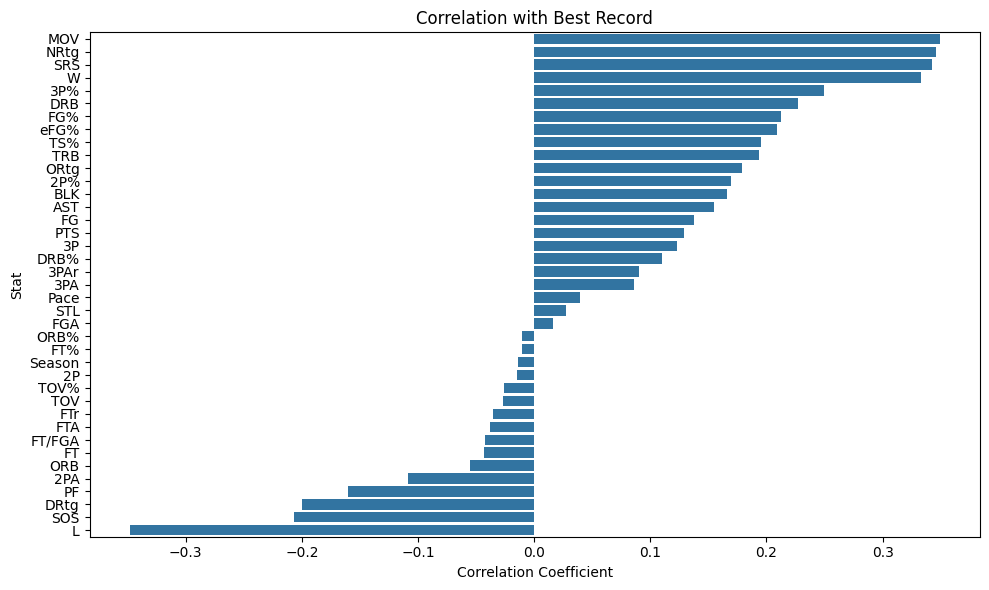

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x=team_corr.values, y=team_corr.index)
plt.title("Correlation with Best Record")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Stat")
plt.tight_layout()
plt.show()

Based on the results here, we're going to take everything with a correlation coefficient >.10

In [21]:
important_stats = team_corr[team_corr > 0.10].index

In [22]:
team_eda = teams_df[list(important_stats) + ["has_Best_Record"]]

In [23]:
print(team_eda.head())
print(f"{team_eda.shape[1]-1} stats selected with correlation > 0.20")

    MOV  NRtg   SRS     W    3P%   DRB    FG%   eFG%    TS%   TRB   ORtg  \
0  4.90   5.1  4.67  54.0  0.412  31.9  0.492  0.546  0.585  43.0  115.3   
1 -3.60  -3.6 -3.28  26.0  0.375  29.2  0.469  0.514  0.557  38.4  108.1   
2  4.09   4.3  4.15  53.0  0.359  30.5  0.468  0.509  0.561  41.4  111.8   
3  5.34   5.7  5.33  53.0  0.364  31.6  0.491  0.524  0.565  42.2  110.7   
4 -1.78  -1.9 -1.83  40.0  0.371  30.6  0.482  0.521  0.564  40.4  111.3   

     2P%  BLK   AST    FG    PTS   3P  DRB%  has_Best_Record  
0  0.520  5.1  23.3  40.7  110.2  8.9  70.8                0  
1  0.499  4.1  22.4  40.6  108.8  7.7  68.5                0  
2  0.500  5.1  21.0  38.1  106.5  6.6  72.4                0  
3  0.519  4.9  26.7  39.4  104.2  5.4  75.6                0  
4  0.512  4.7  22.0  39.0  104.1  6.3  72.9                0  
18 stats selected with correlation > 0.20


Now that we know the correlation between individual stats and the PPG Leader, we're going to check for correlation between individual stats and reduce redundancies

In [25]:
# Select numeric feature columns excluding the target (PPG Leader)
features_only = team_eda.drop(columns=["has_Best_Record"])

In [26]:
# Compute the correlation matrix with absolute values
corr = features_only.corr().abs()

In [27]:
# Convert correlation to disatance (1 - correlation)
distance_matrix = 1 - corr

In [28]:
# Use hierarchical clustering (linkage) on the distance matrix
linkage_matrix = linkage(distance_matrix, method="ward")

C:\Users\bartl\AppData\Local\Temp\ipykernel_67932\187123466.py:2: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(distance_matrix, method="ward")


Plotting and using a dendrogram to determine correlation between columns. Features are joined closer to the left are more correlated

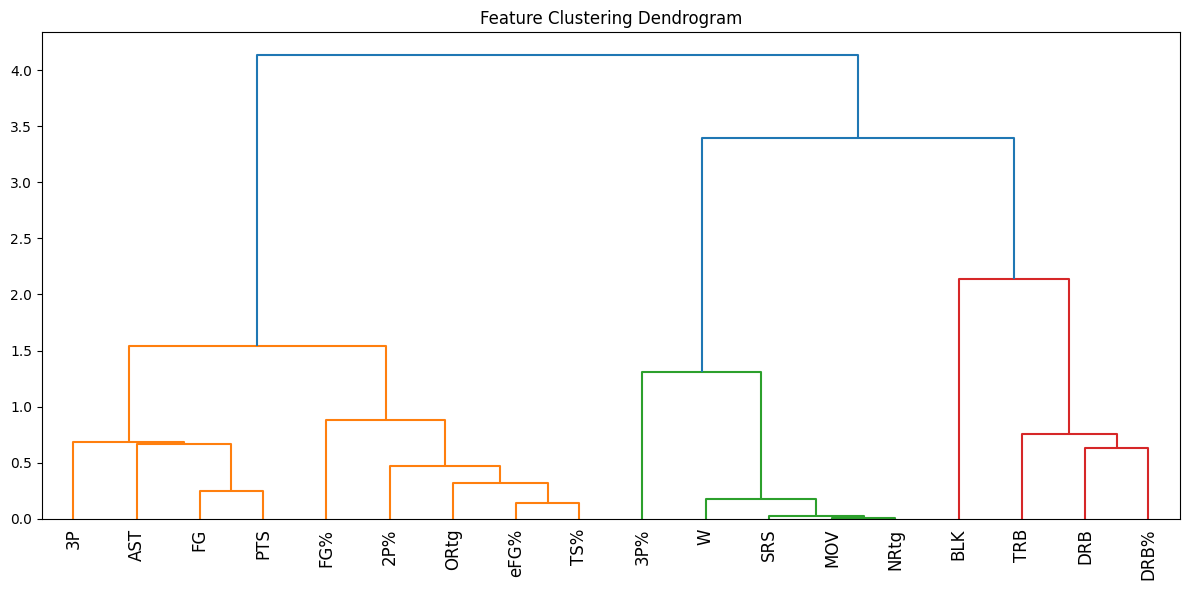

In [29]:
# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=corr.columns, leaf_rotation=90)
plt.title("Feature Clustering Dendrogram")
plt.tight_layout()
plt.show()

In [30]:
feature_corr = team_eda.drop(columns=["W"]).corr()

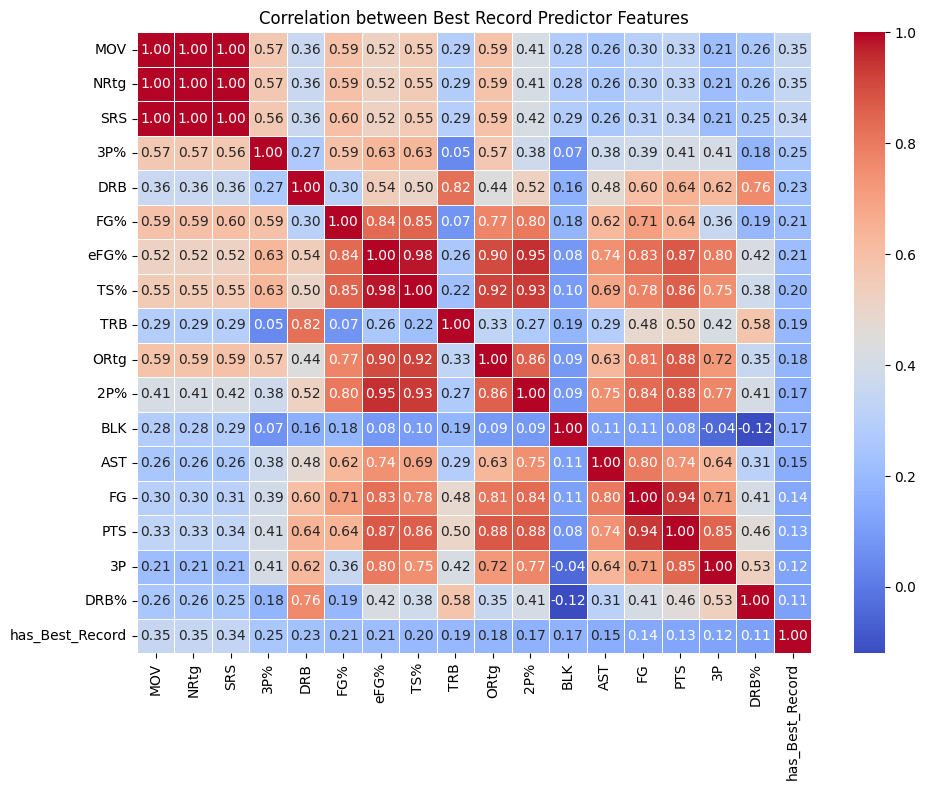

In [32]:
# Visualizing the data using a Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(feature_corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation between Best Record Predictor Features")
plt.tight_layout()
plt.show()

In [34]:
# Creating a correlation matrix of absolute values
corr_matrix = team_eda.drop(columns=["has_Best_Record"]).corr().abs()

In [35]:
# Selecting the upper triangle to avoid duplicate pairs
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

In [36]:
# Finding highly correlated feature pairs (pairs over >.85)
high_corr_features = [
    column for column in upper.columns if any(upper[column] > 0.85)
]
print(f"Features to consider droppong due to high correlation: \n{high_corr_features}")

Features to consider droppong due to high correlation: 
['NRtg', 'SRS', 'W', 'TS%', 'ORtg', '2P%', 'PTS']


Based on domain knowledge, we're not going to drop the suggestion columns from the upper triangle. Instead we're going to use the results of the dendrogram along with the heatmap to decide which columns should be dropped. The criteria remains the same, for a column to be considered for dropping it will be above or close to .85.

In [38]:
columns_to_drop = ["TRB", "W", "SRS", "NRtg", "eFG%", "TS%", "2P%"]
reduced_df = team_eda.drop(columns=columns_to_drop)

In [39]:
reduced_df.head(5)

,MOV,3P%,DRB,FG%,ORtg,BLK,AST,FG,PTS,3P,DRB%,has_Best_Record
0,4.90,0.412,31.9,0.492,115.3,5.1,23.3,40.7,110.2,8.9,70.8,0
1,-3.60,0.375,29.2,0.469,108.1,4.1,22.4,40.6,108.8,7.7,68.5,0
2,4.09,0.359,30.5,0.468,111.8,5.1,21.0,38.1,106.5,6.6,72.4,0
3,5.34,0.364,31.6,0.491,110.7,4.9,26.7,39.4,104.2,5.4,75.6,0
4,-1.78,0.371,30.6,0.482,111.3,4.7,22.0,39.0,104.1,6.3,72.9,0


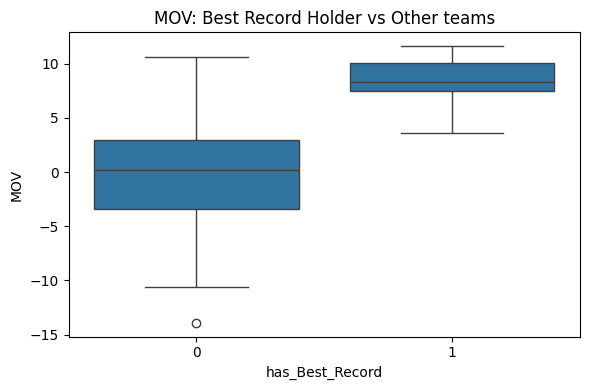

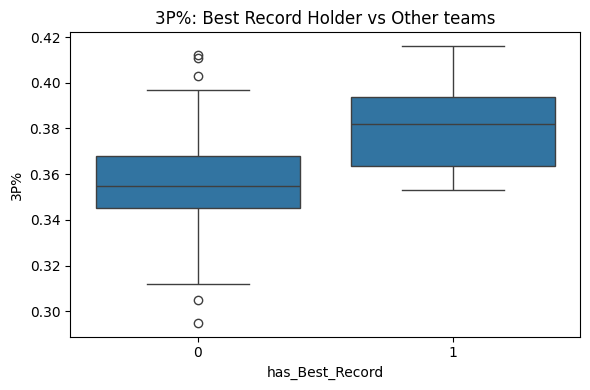

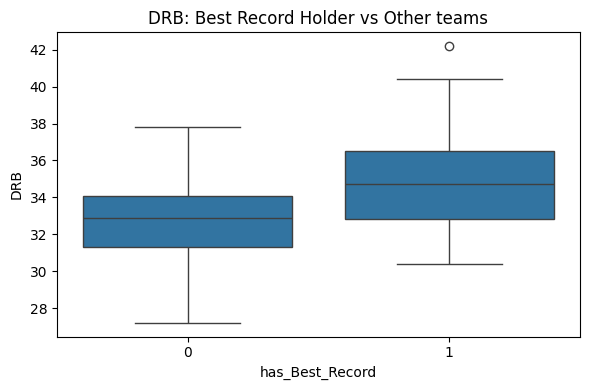

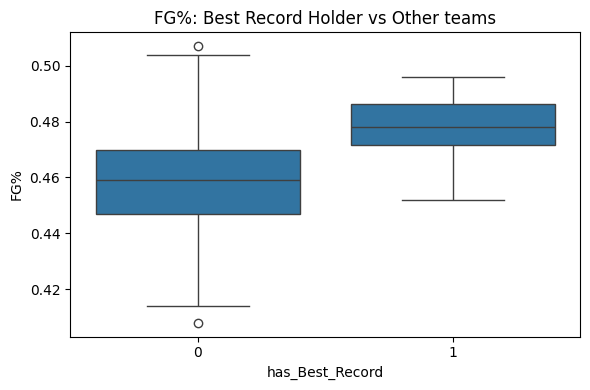

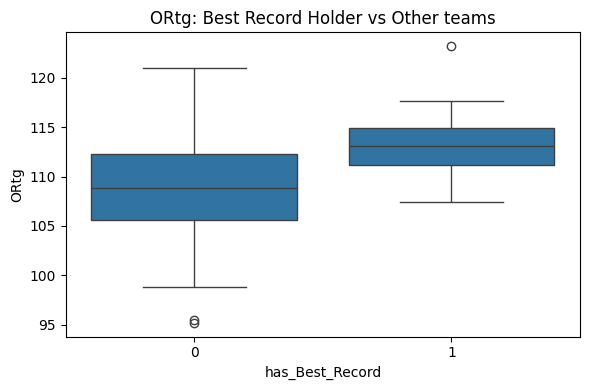

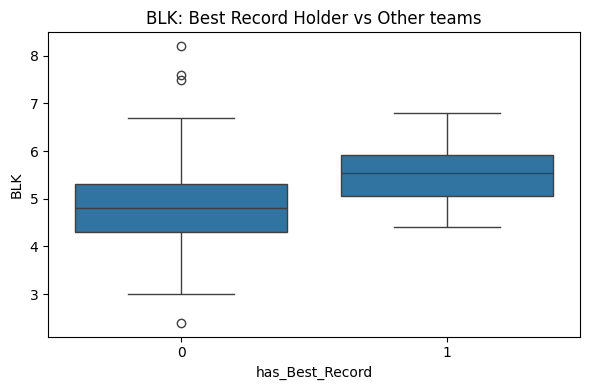

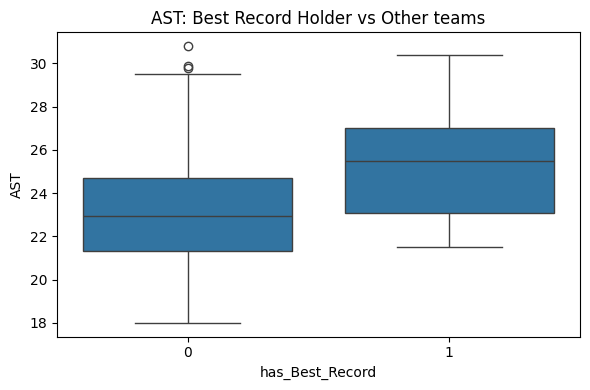

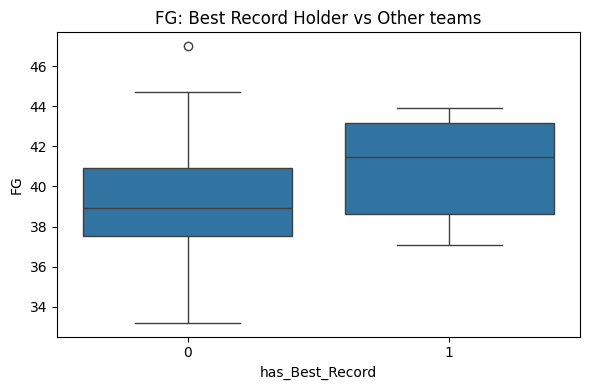

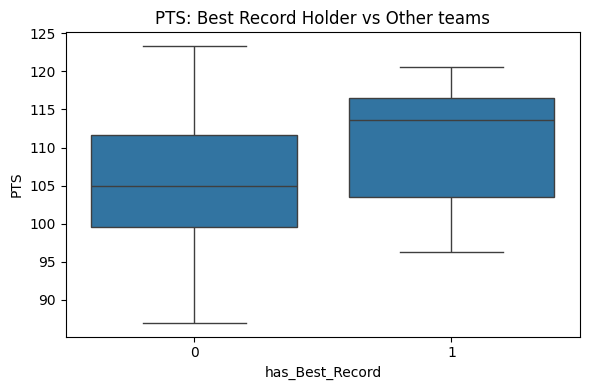

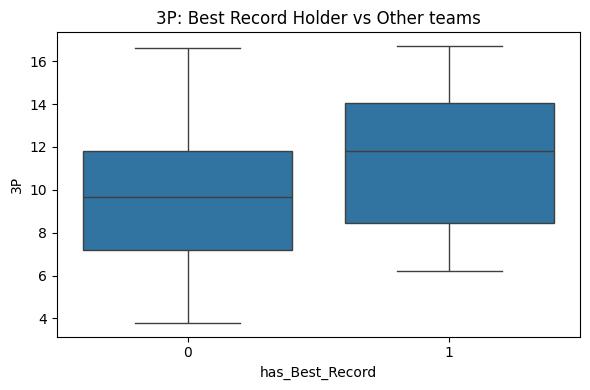

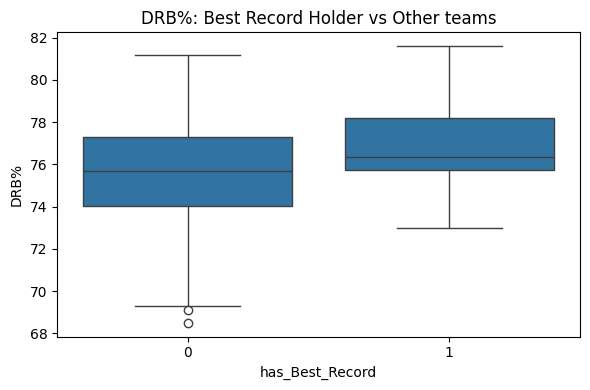

In [40]:
# Visualizing Best Record Holder vs Other teams for Key Features (0 = Other teams, 1 = Best Record Holder)
for col in reduced_df.columns:
    if col != "has_Best_Record":
        plt.figure(figsize=(6,4))
        sns.boxplot(x="has_Best_Record", y=col, data=reduced_df)
        plt.title(f"{col}: Best Record Holder vs Other teams")
        plt.tight_layout()
        plt.show()

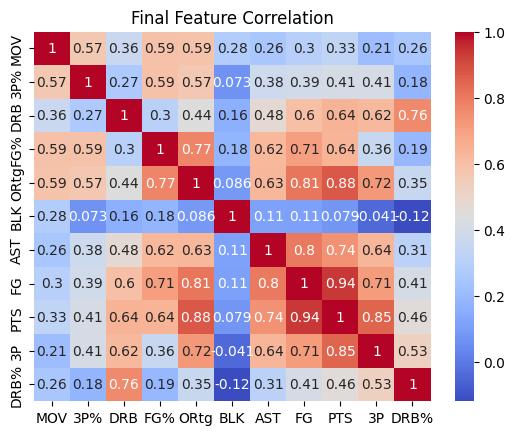

In [42]:
# One last check for redundancy
sns.heatmap(reduced_df.drop(columns="has_Best_Record").corr(), annot=True, cmap="coolwarm")
plt.title("Final Feature Correlation")
plt.show()

In [43]:
# Dropping 2P since it is so closely correlated with FTA
last_drop = ["FG", "ORtg"]
team_eda.drop(columns=last_drop)

,MOV,NRtg,SRS,W,3P%,DRB,FG%,eFG%,TS%,TRB,2P%,BLK,AST,PTS,3P,DRB%,has_Best_Record
0,4.90,5.1,4.67,54.0,0.412,31.9,0.492,0.546,0.585,43.0,0.520,5.1,23.3,110.2,8.9,70.8,0
1,-3.60,-3.6,-3.28,26.0,0.375,29.2,0.469,0.514,0.557,38.4,0.499,4.1,22.4,108.8,7.7,68.5,0
2,4.09,4.3,4.15,53.0,0.359,30.5,0.468,0.509,0.561,41.4,0.500,5.1,21.0,106.5,6.6,72.4,0
3,5.34,5.7,5.33,53.0,0.364,31.6,0.491,0.524,0.565,42.2,0.519,4.9,26.7,104.2,5.4,75.6,0
4,-1.78,-1.9,-1.83,40.0,0.371,30.6,0.482,0.521,0.564,40.4,0.512,4.7,22.0,104.1,6.3,72.9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,1.76,1.8,1.10,46.0,0.370,33.0,0.465,0.538,0.578,42.3,0.527,3.4,25.8,110.1,12.5,78.1,0
446,-9.11,-9.1,-9.06,14.0,0.348,32.8,0.463,0.526,0.562,43.3,0.528,4.7,25.5,109.9,11.0,77.3,0
447,-10.24,-10.5,-10.12,21.0,0.355,31.0,0.460,0.529,0.560,40.3,0.528,4.5,24.8,106.6,12.1,74.5,0
448,-9.02,-9.2,-8.29,21.0,0.345,30.1,0.439,0.503,0.539,42.7,0.494,4.3,23.1,106.4,11.5,74.0,0


In [44]:
reduced_df.to_csv(f"{PROCESSED_PATH}/team_eda_cleaned.csv")
print(f"team_eda_cleaned saved to {PROCESSED_PATH}")

team_eda_cleaned saved to ../../data/processed
